# Phase 2 — XGBoost Default Predictor

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from itertools import product
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print(f'XGBoost version: {xgb.__version__}')

XGBoost version: 3.2.0


## 2. Load Preprocessed Data

In [2]:
X_train = pd.read_csv('preprocessed/X_train.csv')
X_test  = pd.read_csv('preprocessed/X_test.csv')
y_train = pd.read_csv('preprocessed/y_train.csv').squeeze()
y_test  = pd.read_csv('preprocessed/y_test.csv').squeeze()

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')

# Sanity check: positive rate should be ~75-80% after Current exclusion
assert y_train.mean() < 0.85, f'STOP: train positive rate is {y_train.mean():.1%} — Current loans may still be included'

Train: (796918, 167)  |  Test: (341537, 167)
Train positive rate: 78.6%
Test  positive rate: 78.3%


## 3. Restore Features Dropped in Phase 1

Phase 1 dropped `int_rate`, `installment`, `open_acc` based on ablative analysis from the paper's logistic regression. XGBoost handles noisy/correlated features natively — putting them back gives it more signal.

In [3]:
# Restore ablation-dropped columns (saved by Phase 1, properly aligned)
restore_train = pd.read_csv('preprocessed/ablation_restore_train.csv')
restore_test  = pd.read_csv('preprocessed/ablation_restore_test.csv')

for col in ['int_rate', 'installment', 'open_acc']:
    X_train[col] = restore_train[col].values
    X_test[col]  = restore_test[col].values

# NaN guard: these columns were absent during Phase 1's dropna,
# so surviving rows may have NaN in these specific columns.
for col in ['int_rate', 'installment', 'open_acc']:
    fill_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(fill_val)
    X_test[col]  = X_test[col].fillna(fill_val)   # use train median

print(f'Restored: int_rate, installment, open_acc')
print(f'NaN check: {X_train[["int_rate","installment","open_acc"]].isnull().sum().sum()} train, '
      f'{X_test[["int_rate","installment","open_acc"]].isnull().sum().sum()} test')
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Restored: int_rate, installment, open_acc
NaN check: 0 train, 0 test
Train: (796918, 170)  |  Test: (341537, 170)


## 4. Drop Grade / Subgrade Columns

Grade and subgrade are assigned by Lending Club and directly encode their own internal default risk score. When left in, the model's top features were almost entirely grade columns — just re-predicting LC's own assessment. Dropping these forces the model to find signal in the actual borrower data.

Note: `int_rate` is kept despite being correlated with grade — as a continuous feature it lets XGBoost find non-linear splits that the categorical grade encoding can't express.

In [4]:
grade_cols = [c for c in X_train.columns if 'grade' in c.lower()]
print(f'Dropping {len(grade_cols)} grade/subgrade columns:')
print(grade_cols)

X_train = X_train.drop(columns=grade_cols)
X_test  = X_test.drop(columns=[c for c in grade_cols if c in X_test.columns])

print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

Dropping 40 grade/subgrade columns:
['grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'sub_grade_A2', 'sub_grade_A3', 'sub_grade_A4', 'sub_grade_A5', 'sub_grade_B1', 'sub_grade_B2', 'sub_grade_B3', 'sub_grade_B4', 'sub_grade_B5', 'sub_grade_C1', 'sub_grade_C2', 'sub_grade_C3', 'sub_grade_C4', 'sub_grade_C5', 'sub_grade_D1', 'sub_grade_D2', 'sub_grade_D3', 'sub_grade_D4', 'sub_grade_D5', 'sub_grade_E1', 'sub_grade_E2', 'sub_grade_E3', 'sub_grade_E4', 'sub_grade_E5', 'sub_grade_F1', 'sub_grade_F2', 'sub_grade_F3', 'sub_grade_F4', 'sub_grade_F5', 'sub_grade_G1', 'sub_grade_G2', 'sub_grade_G3', 'sub_grade_G4', 'sub_grade_G5']

Train: (796918, 130)  |  Test: (341537, 130)


## 5. Add Derived Features

In [5]:
def add_features(df):
    df = df.copy()

    # Loan-to-income ratio
    if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
        df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

    # FICO midpoint (replace low/high with single feature)
    if 'fico_range_low' in df.columns and 'fico_range_high' in df.columns:
        df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high']) / 2
        df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

    # Revolving utilization as fraction
    if 'revol_util' in df.columns:
        df['revol_util_frac'] = df['revol_util'] / 100

    # Credit history length in months
    if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
        df['cr_history_months'] = df['issue_d'] - df['earliest_cr_line']

    # Monthly payment as fraction of monthly income
    if 'installment' in df.columns and 'annual_inc' in df.columns:
        df['payment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

    # Revolving balance relative to income
    if 'revol_bal' in df.columns and 'annual_inc' in df.columns:
        df['revol_bal_to_inc'] = df['revol_bal'] / (df['annual_inc'] + 1)

    # Combined derogatory marks
    if 'pub_rec' in df.columns and 'delinq_2yrs' in df.columns:
        df['derog_marks'] = df['pub_rec'] + df['delinq_2yrs']

    # Inquiry intensity per account
    if 'inq_last_6mths' in df.columns and 'open_acc' in df.columns:
        df['inq_per_account'] = df['inq_last_6mths'] / (df['open_acc'] + 1)

    # Monthly debt burden in dollars (dti is a %, this scales it)
    if 'dti' in df.columns and 'annual_inc' in df.columns:
        df['monthly_debt'] = df['dti'] * df['annual_inc'] / 1200

    # Fraction of accounts that have been closed (credit maturity)
    if 'total_acc' in df.columns and 'open_acc' in df.columns:
        df['closed_acc_ratio'] = (df['total_acc'] - df['open_acc']) / (df['total_acc'] + 1)

    # Guard against inf/NaN from divisions
    for c in df.select_dtypes(include='number').columns:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)

    return df

X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'NaN remaining: train={X_train.isnull().sum().sum()}, test={X_test.isnull().sum().sum()}')

Train: (796918, 138)  |  Test: (341537, 138)
NaN remaining: train=0, test=0


## 6. Build DMatrix — No Sample Weights

Previous version used 3.68x sample weights on defaults to rebalance the classes. This *destroyed* performance — AUC dropped to 0.735 and G-mean to 67.2 because the weights warped the probability surface: the model output ~0.5 for everything, making threshold selection useless.

The paper's models (LR, NB, SVM) all trained on the natural ~80/20 distribution with NO rebalancing. The threshold sweep (Section 12) is the right tool for adjusting the sensitivity/specificity tradeoff — not sample weights.

For a lending default problem, this makes sense: the 80/20 split reflects the real prior probability that a loan will be repaid. Reweighting tells the model to pretend defaults are 50% of loans, which produces poorly calibrated probabilities.

In [6]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

print(f'Negatives (default):      {n_neg:,}  ({n_neg/len(y_train):.1%})')
print(f'Positives (non-default):  {n_pos:,}  ({n_pos/len(y_train):.1%})')
print(f'Training on natural distribution — no sample weights')

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

Negatives (default):      170,228  (21.4%)
Positives (non-default):  626,690  (78.6%)
Training on natural distribution — no sample weights


## 7. Round 1 — Find Optimal Number of Trees

In [7]:
params_r1 = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 50,
    'gamma':            1,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'seed':             42,
    'nthread':          -1,
}

evals_r1 = {}
model_r1 = xgb.train(
    params_r1, dtrain,
    num_boost_round       = 1000,
    evals                 = [(dtrain, 'train'), (dtest, 'test')],
    evals_result          = evals_r1,
    early_stopping_rounds = 40,
    verbose_eval          = 100,
)

best_round_r1 = model_r1.best_iteration
print(f'\nBest round: {best_round_r1}  |  Best test AUC: {model_r1.best_score:.4f}')

[0]	train-auc:0.71272	test-auc:0.67114
[100]	train-auc:0.74834	test-auc:0.72175
[200]	train-auc:0.75459	test-auc:0.72642
[300]	train-auc:0.75918	test-auc:0.72890
[400]	train-auc:0.76281	test-auc:0.73044
[500]	train-auc:0.76630	test-auc:0.73170
[600]	train-auc:0.76920	test-auc:0.73244
[700]	train-auc:0.77202	test-auc:0.73306
[800]	train-auc:0.77476	test-auc:0.73351
[900]	train-auc:0.77725	test-auc:0.73385
[999]	train-auc:0.77983	test-auc:0.73414

Best round: 999  |  Best test AUC: 0.7341


## 8. Hyperparameter Tuning

Grid covers: `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`.

In [8]:
param_grid = {
    'max_depth':        [4, 6, 8],
    'min_child_weight': [20, 50, 100],
    'subsample':        [0.7, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma':            [0, 1, 5],
}

fixed = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'learning_rate':    0.05,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'seed':             42,
    'nthread':          -1,
}

n_rounds = int(best_round_r1 * 1.2)
combos = list(product(*param_grid.values()))
keys   = list(param_grid.keys())
print(f'Grid: {len(combos)} configs × {n_rounds} rounds each')

tuning_results = []

for i, combo in enumerate(combos):
    params = {**fixed, **dict(zip(keys, combo))}
    er = {}
    xgb.train(
        params, dtrain,
        num_boost_round       = n_rounds,
        evals                 = [(dtest, 'test')],
        evals_result          = er,
        early_stopping_rounds = 30,
        verbose_eval          = False,
    )
    best_auc = max(er['test']['auc'])
    tuning_results.append({**dict(zip(keys, combo)), 'test_auc': round(best_auc, 4)})
    if (i + 1) % 18 == 0 or i == len(combos) - 1:
        print(f'  [{i+1}/{len(combos)}] done')

tuning_df = pd.DataFrame(tuning_results).sort_values('test_auc', ascending=False)
print()
print('Top 10 configs:')
print(tuning_df.head(10).to_string(index=False))

Grid: 108 configs × 1198 rounds each
  [18/108] done
  [36/108] done
  [54/108] done
  [72/108] done
  [90/108] done
  [108/108] done

Top 10 configs:
 max_depth  min_child_weight  subsample  colsample_bytree  gamma  test_auc
         8               100        0.8               0.8      1    0.7348
         6               100        0.7               0.8      0    0.7347
         6               100        0.8               0.8      1    0.7347
         8               100        0.8               0.8      0    0.7346
         8               100        0.8               0.6      0    0.7346
         6               100        0.8               0.6      1    0.7346
         6               100        0.8               0.6      0    0.7346
         6                50        0.8               0.6      1    0.7346
         8                50        0.8               0.6      1    0.7346
         6                50        0.7               0.8      1    0.7345


## 9. Final Model — Best Params + Lower Learning Rate

In [9]:
best_row = tuning_df.iloc[0]

params_final = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'max_depth':        int(best_row['max_depth']),
    'min_child_weight': int(best_row['min_child_weight']),
    'subsample':        float(best_row['subsample']),
    'colsample_bytree': float(best_row['colsample_bytree']),
    'gamma':            float(best_row['gamma']),
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'learning_rate':    0.02,
    'seed':             42,
    'nthread':          -1,
}

print('Final params:', params_final)

evals_final = {}
model_final = xgb.train(
    params_final, dtrain,
    num_boost_round       = 3000,
    evals                 = [(dtrain, 'train'), (dtest, 'test')],
    evals_result          = evals_final,
    early_stopping_rounds = 50,
    verbose_eval          = 200,
)

print(f'\nBest round: {model_final.best_iteration}  |  Best test AUC: {model_final.best_score:.4f}')

Final params: {'objective': 'binary:logistic', 'eval_metric': 'auc', 'max_depth': 8, 'min_child_weight': 100, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'learning_rate': 0.02, 'seed': 42, 'nthread': -1}
[0]	train-auc:0.71857	test-auc:0.67547
[200]	train-auc:0.75495	test-auc:0.72355
[400]	train-auc:0.76197	test-auc:0.72802
[600]	train-auc:0.76714	test-auc:0.73042
[800]	train-auc:0.77157	test-auc:0.73203
[1000]	train-auc:0.77577	test-auc:0.73319
[1200]	train-auc:0.77972	test-auc:0.73392
[1400]	train-auc:0.78328	test-auc:0.73444
[1600]	train-auc:0.78662	test-auc:0.73477
[1800]	train-auc:0.79006	test-auc:0.73501
[2000]	train-auc:0.79321	test-auc:0.73521
[2200]	train-auc:0.79638	test-auc:0.73536
[2272]	train-auc:0.79744	test-auc:0.73536

Best round: 2222  |  Best test AUC: 0.7354


## 10. Training Curve

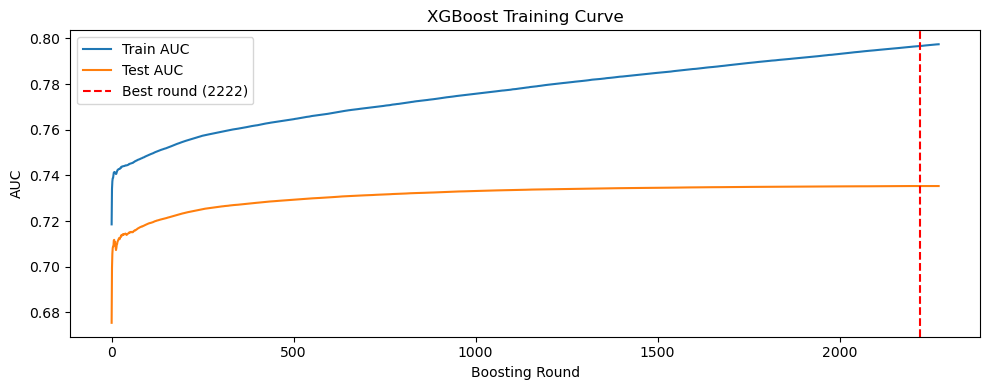

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(evals_final['train']['auc'], label='Train AUC')
plt.plot(evals_final['test']['auc'],  label='Test AUC')
plt.axvline(model_final.best_iteration, color='red', linestyle='--',
            label=f'Best round ({model_final.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('preprocessed/xgb_training_curve.png', dpi=150)
plt.show()

## 11. Evaluate — Paper Metrics

In [11]:
def paper_metrics(y_true, y_pred_binary):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    accuracy    = (tn + tp) / len(y_true)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_mean      = np.sqrt(sensitivity * specificity)
    return {
        'Accuracy':    round(accuracy    * 100, 1),
        'Precision':   round(precision   * 100, 1),
        'Sensitivity': round(sensitivity * 100, 1),
        'Specificity': round(specificity * 100, 1),
        'G-mean':      round(g_mean      * 100, 1),
    }

y_prob = model_final.predict(dtest)
auc    = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC: {auc:.4f}')
print()
m50 = paper_metrics(y_test, (y_prob >= 0.5).astype(int))
print('@ threshold=0.50:')
for k, v in m50.items():
    print(f'  {k:<14}: {v}')

ROC-AUC: 0.7354

@ threshold=0.50:
  Accuracy      : 79.2
  Precision     : 80.6
  Sensitivity   : 96.7
  Specificity   : 15.8
  G-mean        : 39.2


## 12. Threshold Sweep

In [12]:
rows = []
for t in np.arange(0.1, 0.91, 0.01):
    m = paper_metrics(y_test, (y_prob >= t).astype(int))
    m['Threshold'] = round(float(t), 2)
    rows.append(m)

sweep_df   = pd.DataFrame(rows)[['Threshold','Accuracy','Precision','Sensitivity','Specificity','G-mean']]
best_gmean = sweep_df.loc[sweep_df['G-mean'].idxmax()]
best_spec  = sweep_df.loc[sweep_df['Specificity'].idxmax()]

print('Best G-mean threshold:')
print(best_gmean.to_string())
print()
print('Best Specificity threshold:')
print(best_spec.to_string())

Best G-mean threshold:
Threshold       0.77
Accuracy       67.30
Precision      88.10
Sensitivity    67.30
Specificity    67.00
G-mean         67.20

Best Specificity threshold:
Threshold       0.9
Accuracy       43.0
Precision      93.8
Sensitivity    29.2
Specificity    93.0
G-mean         52.1


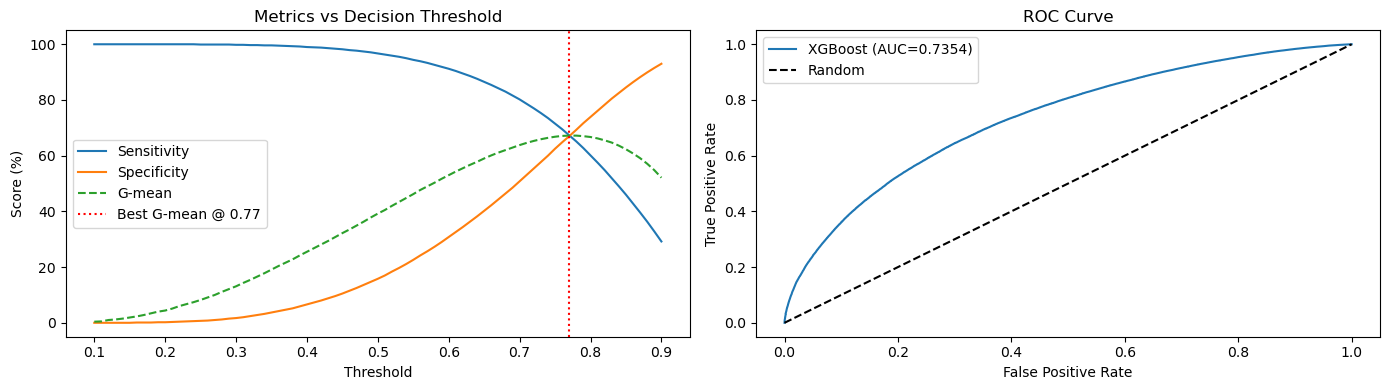

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sweep_df['Threshold'], sweep_df['Sensitivity'], label='Sensitivity')
axes[0].plot(sweep_df['Threshold'], sweep_df['Specificity'], label='Specificity')
axes[0].plot(sweep_df['Threshold'], sweep_df['G-mean'],      label='G-mean', linestyle='--')
axes[0].axvline(best_gmean['Threshold'], color='red', linestyle=':',
                label=f"Best G-mean @ {best_gmean['Threshold']}")
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Metrics vs Decision Threshold')
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('preprocessed/xgb_roc_threshold.png', dpi=150)
plt.show()

## 13. Final Results vs Paper

In [14]:
best_t  = best_gmean['Threshold']
final_m = paper_metrics(y_test, (y_prob >= best_t).astype(int))

comparison = pd.DataFrame([
    {'Model': 'Logistic Regression (paper)', 'Accu': 92.8, 'Prec': 96.6, 'Sens': 95.1, 'Spec': 77.1, 'G-mean': 85.7},
    {'Model': 'Gaussian Naive Bayes (paper)','Accu': 91.1, 'Prec': 96.6, 'Sens': 92.7, 'Spec': 80.4, 'G-mean': 86.3},
    {'Model': 'SVM Linear (paper)',          'Accu': 93.7, 'Prec': 96.9, 'Sens': 96.3, 'Spec': 78.0, 'G-mean': 86.7},
    {'Model': 'XGBoost (ours)',
     'Accu':   final_m['Accuracy'],   'Prec':   final_m['Precision'],
     'Sens':   final_m['Sensitivity'],'Spec':   final_m['Specificity'],
     'G-mean': final_m['G-mean']},
])

print(f'Threshold: {best_t}  |  ROC-AUC: {auc:.4f}')
print()
print(comparison.to_string(index=False))

Threshold: 0.77  |  ROC-AUC: 0.7354

                       Model  Accu  Prec  Sens  Spec  G-mean
 Logistic Regression (paper)  92.8  96.6  95.1  77.1    85.7
Gaussian Naive Bayes (paper)  91.1  96.6  92.7  80.4    86.3
          SVM Linear (paper)  93.7  96.9  96.3  78.0    86.7
              XGBoost (ours)  67.3  88.1  67.3  67.0    67.2


## 14. Feature Importance

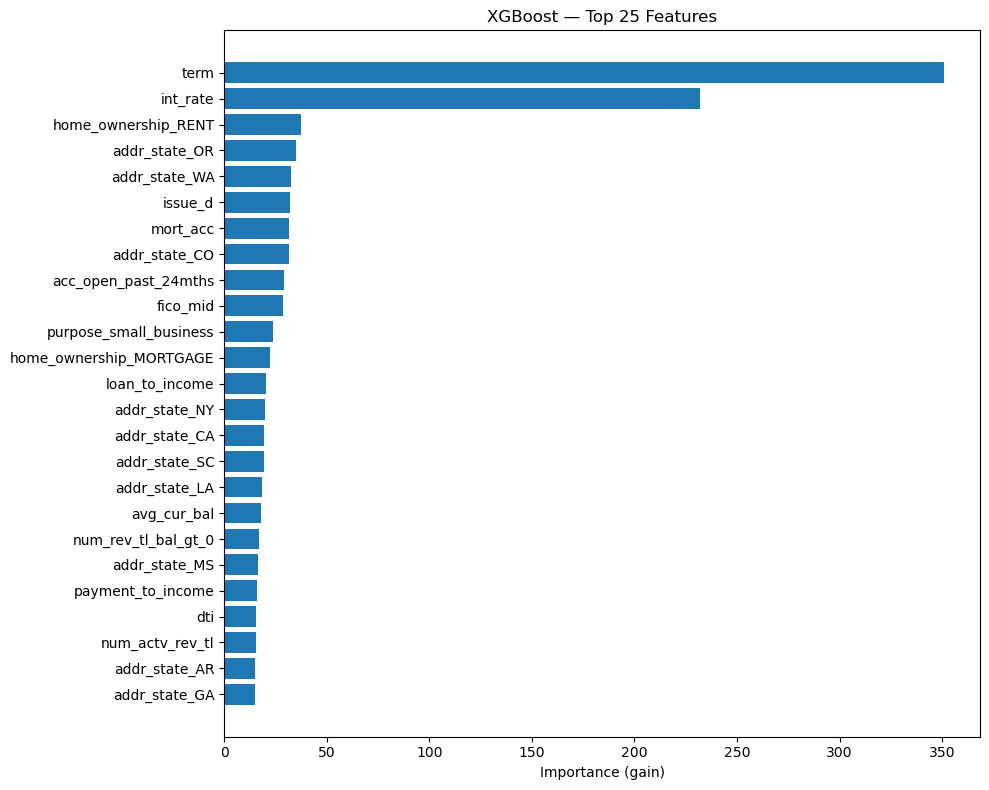

Top 10:
             feature       gain
                term 350.888000
            int_rate 231.939789
 home_ownership_RENT  37.590626
       addr_state_OR  34.942738
       addr_state_WA  32.778141
             issue_d  32.193596
            mort_acc  31.469440
       addr_state_CO  31.343348
acc_open_past_24mths  29.068993
            fico_mid  28.550108


In [15]:
scores = model_final.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(scores.keys()), 'gain': list(scores.values())})
imp_df = imp_df.sort_values('gain', ascending=False).head(25)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'][::-1], imp_df['gain'][::-1])
plt.xlabel('Importance (gain)')
plt.title('XGBoost — Top 25 Features')
plt.tight_layout()
plt.savefig('preprocessed/xgb_feature_importance.png', dpi=150)
plt.show()

print('Top 10:')
print(imp_df.head(10).to_string(index=False))

## 15. Save

In [16]:
model_final.save_model('preprocessed/xgb_model.ubj')
sweep_df.to_csv('preprocessed/xgb_threshold_sweep.csv', index=False)
imp_df.to_csv('preprocessed/xgb_feature_importance.csv', index=False)

print('Saved to ./preprocessed/')

Saved to ./preprocessed/
